# Person 4 — Out-of-sample backtest, January 2020–December 2025

This notebook consumes Person 3's committed monthly exports and evaluates **12 strategies**: 25, 50, or 100 candidates, two benchmarks, and representative or optimized weights. It reads Part 3's files without executing or modifying `part3.ipynb`.

At month-end t, Person 3 forms a portfolio using information through t; Person 4 applies its saved weights to realized returns in t+1. The updated Part 3 policy drops incomplete benchmark observations **inside the previous 60-month window**, retaining at least 48 training observations. Part 2's stock selection still uses its complete stock histories.

The requested test period has **72 months, January 2020–December 2025**. Missing realized portfolio or benchmark returns are audited separately from training exclusions. The common comparison contains only months where all 12 strategies can be evaluated. Cumulative performance restarts after an unavailable test month.

Run all cells from the repository directory. The notebook exports tables and figures to `part4_output/` and retains displayed results here.


## 1. Inputs and policy

Required Person 1 data:
- `top500_data/top500_formations.csv`
- `top500_data/selected_stock_monthly_history.csv`

Required Person 3 handoff (committed to this repository):
- `part3_output/monthly_weights_2020-01_to_2025-12.csv`
- `part3_output/monthly_weight_diagnostics_2020-01_to_2025-12.csv`
- `part3_output/benchmark_returns_2020-01_to_2025-12.csv`

The benchmark export includes training history as well as test months. We verify its covered dates against benchmarks reconstructed from Person 1's lagged holdings. The diagnostics disclose the exact training dates dropped by Person 3. Earlier files named `portfolio_weights.csv` or `excluded_formation_months.csv` belong to the old run and are **not used**.

A missing positive-weight stock return invalidates that portfolio observation; an exactly zero-weight position does not require a return. Missing realized benchmark returns cannot be repaired by the training-window drop policy. The comparison uses common dates for all 12 strategies and discloses every exclusion.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from portfolio_weighting import build_benchmark_returns

ROOT = Path.cwd()
DATA_DIR = ROOT / "top500_data"
PART3_DIR = ROOT / "part3_output"
OUTPUT_DIR = ROOT / "part4_output"
K_VALUES = (25, 50, 100)
BENCHMARKS = ("value_weighted", "equal_weighted")
METHODS = ("representative", "optimized")
START_HOLDING = "2020-01"
END_HOLDING = "2025-12"
LOOKBACK = 60
MIN_TRAINING_MONTHS = 48
EXPORT_SUFFIX = "2020-01_to_2025-12.csv"
STRATEGY_KEYS = ["k", "benchmark", "method"]
PORTFOLIO_KEYS = ["holding_month"] + STRATEGY_KEYS
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})


## 2. Backtest functions

For each holding month, portfolio return is the sum of beginning-of-month weights times that month's stock returns. Date, PERMNO, uniqueness, candidate count, and long-only/full-investment checks prevent accidental misalignment.

Turnover at the start of a holding month is half the absolute weight change, measured against the previous portfolio **after its returns have drifted its weights**. The union of old and new PERMNOs includes exits and entries. Initial investment is excluded. Turnover is unavailable after missing previous portfolio data, a gap in weights, or complete loss of the previous portfolio; it is never assumed to be zero.


In [2]:
def normalize(frame, required, unique_keys, month_columns):
    """Normalize a handoff table without mutating the caller's data."""
    missing = set(required) - set(frame.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    frame = frame.copy()
    for name in month_columns:
        frame[name] = pd.PeriodIndex(frame[name], freq="M")
    if frame[list(unique_keys)].isna().any().any():
        raise ValueError(f"Null keys: {unique_keys}")
    if frame.duplicated(list(unique_keys)).any():
        raise ValueError(f"Duplicate keys: {unique_keys}")
    return frame


def evaluate_portfolios(weights, history, benchmarks, k_values=K_VALUES):
    """Evaluate saved t weights on t+1 returns; return observations and positions."""
    weights = normalize(
        weights,
        ["formation_month", "holding_month", "k", "benchmark", "method", "permno", "weight"],
        PORTFOLIO_KEYS + ["permno"], ["formation_month", "holding_month"],
    )
    history = normalize(history, ["month", "permno", "mthret"],
                        ["month", "permno"], ["month"])
    benchmarks = normalize(benchmarks, ["month"] + list(BENCHMARKS), ["month"], ["month"])
    if weights.empty:
        raise ValueError("No portfolio weights")
    if not weights["holding_month"].eq(weights["formation_month"] + 1).all():
        raise ValueError("Weights must apply exactly one month after formation")
    if not weights["k"].isin(k_values).all():
        raise ValueError("Unexpected candidate count k")
    if not weights["benchmark"].isin(BENCHMARKS).all() or not weights["method"].isin(METHODS).all():
        raise ValueError("Unexpected benchmark or weighting method")
    weights["weight"] = pd.to_numeric(weights["weight"], errors="raise")
    if not np.isfinite(weights["weight"]).all() or weights["weight"].lt(0).any():
        raise ValueError("Weights must be finite and nonnegative")
    checks = weights.groupby(PORTFOLIO_KEYS)["weight"].agg(["sum", "size"])
    if not np.allclose(checks["sum"], 1, rtol=0, atol=1e-7):
        raise ValueError("Portfolio weights must sum to one")
    if not np.array_equal(checks["size"], checks.index.get_level_values("k")):
        raise ValueError("Each portfolio must contain exactly k distinct candidates")
    # Normalize roundoff only after checking the exported weights.
    weights["weight"] /= weights.groupby(PORTFOLIO_KEYS)["weight"].transform("sum")
    history["mthret"] = pd.to_numeric(history["mthret"], errors="raise")
    for name in BENCHMARKS:
        benchmarks[name] = pd.to_numeric(benchmarks[name], errors="raise")

    positions = weights.merge(
        history.rename(columns={"month": "holding_month"})[["holding_month", "permno", "mthret"]],
        on=["holding_month", "permno"], how="left", validate="many_to_one",
    )
    positions["invalid_return"] = (
        positions["weight"].gt(0)
        & (~np.isfinite(positions["mthret"]) | positions["mthret"].lt(-1))
    )
    # Only the exactly zero-weight rows can safely have an unused missing return.
    positions["contribution"] = np.where(
        positions["weight"].eq(0), 0.0, positions["weight"] * positions["mthret"]
    )
    b = benchmarks.set_index("month")
    rows = []
    for keys, group in positions.groupby(PORTFOLIO_KEYS, sort=True):
        month, k, benchmark, method = keys
        bad = group.loc[group["invalid_return"], "permno"].tolist()
        rp = float(group["contribution"].sum()) if not bad else np.nan
        rb = float(b.loc[month, benchmark]) if month in b.index else np.nan
        valid_b = bool(np.isfinite(rb) and rb >= -1)
        reasons = []
        if bad:
            reasons.append("missing/invalid held-stock return")
        if not valid_b:
            reasons.append("missing/invalid benchmark return")
        rows.append(dict(
            holding_month=month, formation_month=month - 1, k=k,
            benchmark=benchmark, method=method, portfolio_return=rp,
            benchmark_return=rb if valid_b else np.nan,
            active_return=rp - rb if not reasons else np.nan,
            n_positive_weights=int(group["weight"].gt(0).sum()),
            n_invalid_returns=len(bad), invalid_permnos=";".join(map(str, bad)),
            valid=not reasons, reason="; ".join(reasons),
        ))
    monthly = pd.DataFrame(rows)

    # Calculate turnover on the full available sequence BEFORE common-date filtering.
    monthly["turnover"] = np.nan
    monthly["turnover_status"] = "no previous portfolio"
    for strategy, group in monthly.groupby(STRATEGY_KEYS, sort=True):
        k, benchmark, method = strategy
        p = positions.loc[
            positions["k"].eq(k) & positions["benchmark"].eq(benchmark)
            & positions["method"].eq(method)
        ]
        by_month = {m: g.set_index("permno") for m, g in p.groupby("holding_month")}
        for idx, row in group.iterrows():
            month = row["holding_month"]
            previous = by_month.get(month - 1)
            if previous is None:
                continue
            if previous["invalid_return"].any():
                monthly.loc[idx, "turnover_status"] = "previous held-stock return missing"
                continue
            gross = np.where(previous["weight"].eq(0), 0.0,
                             previous["weight"] * (1 + previous["mthret"]))
            wealth = float(gross.sum())
            if wealth <= 0 or not np.isfinite(wealth):
                monthly.loc[idx, "turnover_status"] = "previous portfolio depleted"
                continue
            drifted = pd.Series(gross / wealth, index=previous.index)
            target = by_month[month]["weight"]
            union = drifted.index.union(target.index)
            monthly.loc[idx, "turnover"] = 0.5 * (
                target.reindex(union, fill_value=0) - drifted.reindex(union, fill_value=0)
            ).abs().sum()
            monthly.loc[idx, "turnover_status"] = "observed"
    return monthly, positions


def common_sample(monthly, start, end, k_values=K_VALUES):
    """Audit every requested strategy-month and identify contiguous common blocks."""
    start, end = pd.Period(start, freq="M"), pd.Period(end, freq="M")
    if end < start:
        raise ValueError("End precedes start")
    calendar = pd.period_range(start, end, freq="M")
    expected = pd.MultiIndex.from_product(
        [calendar, k_values, BENCHMARKS, METHODS], names=PORTFOLIO_KEYS
    )
    audit = monthly.set_index(PORTFOLIO_KEYS).reindex(expected).reset_index()
    absent = audit["valid"].isna()
    audit.loc[absent, "reason"] = "missing Part 3 weights"
    audit["valid"] = audit["valid"].eq(True)
    common_dates = audit.groupby("holding_month")["valid"].all()
    dates = common_dates.index[common_dates]
    audit["included_common_sample"] = audit["holding_month"].isin(dates)
    audit.loc[audit["valid"] & ~audit["included_common_sample"], "reason"] = (
        "excluded to match another strategy's missing observation"
    )
    panel = audit.loc[audit["included_common_sample"]].copy()
    # Restart growth curves after gaps; never compound across an unobserved month.
    block = {}
    block_id, previous = 0, None
    for month in dates:
        if previous is None or month != previous + 1:
            block_id += 1
        block[month] = block_id
        previous = month
    panel["block"] = panel["holding_month"].map(block).astype(int)
    return panel, audit


def summarize(panel):
    """Monthly statistics on common dates and wealth/CAGR only within continuous blocks."""
    if panel.empty:
        raise ValueError("No common valid holding months; inspect the coverage audit")
    summary_rows = []
    for keys, g in panel.groupby(STRATEGY_KEYS, sort=True):
        active = g["active_return"]
        rp, rb = g["portfolio_return"], g["benchmark_return"]
        correlation = rp.corr(rb) if len(g) > 1 and rp.std() > 0 and rb.std() > 0 else np.nan
        summary_rows.append(dict(
            zip(STRATEGY_KEYS, keys),
            n_months=len(g), first_month=str(g["holding_month"].min()),
            last_month=str(g["holding_month"].max()), n_blocks=g["block"].nunique(),
            mean_tracking_difference_monthly=active.mean(),
            mean_tracking_difference_annualized=12 * active.mean(),
            tracking_error_monthly=active.std(ddof=1),
            tracking_error_annualized=np.sqrt(12) * active.std(ddof=1),
            rmse_monthly=np.sqrt(np.mean(active ** 2)),
            correlation=correlation, mean_turnover=g["turnover"].mean(),
            n_turnover_observations=g["turnover"].count(),
        ))
    curves = panel.sort_values(PORTFOLIO_KEYS).copy()
    curves["portfolio_wealth"] = np.nan
    curves["benchmark_wealth"] = np.nan
    block_rows = []
    for keys, g in curves.groupby(STRATEGY_KEYS + ["block"], sort=True):
        g = g.sort_values("holding_month")
        wp = (1 + g["portfolio_return"]).cumprod()
        wb = (1 + g["benchmark_return"]).cumprod()
        curves.loc[g.index, "portfolio_wealth"] = wp
        curves.loc[g.index, "benchmark_wealth"] = wb
        block_rows.append(dict(
            zip(STRATEGY_KEYS + ["block"], keys),
            start=str(g["holding_month"].min()), end=str(g["holding_month"].max()),
            n_months=len(g), portfolio_cumulative_return=wp.iloc[-1] - 1,
            benchmark_cumulative_return=wb.iloc[-1] - 1,
            cumulative_return_difference=wp.iloc[-1] - wb.iloc[-1],
            portfolio_cagr=wp.iloc[-1] ** (12 / len(g)) - 1,
            benchmark_cagr=wb.iloc[-1] ** (12 / len(g)) - 1,
        ))
    return pd.DataFrame(summary_rows), pd.DataFrame(block_rows), curves


def validate_training_handoff(diagnostics, weights, benchmarks, lookback=60, min_training=48):
    """Audit the saved training policy; never refit Person 3's weights."""
    d = normalize(
        diagnostics,
        PORTFOLIO_KEYS + ["formation_month", "training_start", "training_end",
                         "n_training_months", "missing_benchmark_policy",
                         "n_excluded_training_months", "excluded_training_months"],
        PORTFOLIO_KEYS, ["formation_month", "holding_month", "training_start", "training_end"],
    )
    if d.empty:
        raise ValueError("Part 3 training diagnostics are empty")
    if not (
        d["training_end"].eq(d["formation_month"]).all()
        and d["training_start"].eq(d["formation_month"] - lookback + 1).all()
        and d["holding_month"].eq(d["formation_month"] + 1).all()
    ):
        raise ValueError("Training dates must end at formation and span the prior 60-month window")
    wkeys = weights[PORTFOLIO_KEYS].copy()
    wkeys["holding_month"] = pd.PeriodIndex(wkeys["holding_month"], freq="M")
    if set(map(tuple, wkeys.drop_duplicates().to_numpy())) != set(map(tuple, d[PORTFOLIO_KEYS].to_numpy())):
        raise ValueError("Part 3 diagnostics and weights contain different portfolios")
    exclusion_rows = []
    for row in d.itertuples(index=False):
        calendar = pd.period_range(row.training_start, row.training_end, freq="M")
        values = benchmarks.reindex(calendar)[list(BENCHMARKS)].to_numpy(dtype=float)
        actual_bad = list(calendar[~np.isfinite(values).all(axis=1)].astype(str))
        listed = [] if pd.isna(row.excluded_training_months) or not str(row.excluded_training_months).strip() else str(row.excluded_training_months).split(";")
        if listed != actual_bad:
            raise ValueError(f"{row.holding_month}: excluded training dates differ from the benchmark audit")
        n_complete = lookback - len(actual_bad)
        if row.n_training_months != n_complete or row.n_excluded_training_months != len(actual_bad):
            raise ValueError(f"{row.holding_month}: inconsistent training observation counts")
        if row.missing_benchmark_policy == "drop":
            if n_complete < min_training:
                raise ValueError(f"{row.holding_month}: fewer than {min_training} valid training observations")
        elif row.missing_benchmark_policy == "raise":
            if actual_bad:
                raise ValueError(f"{row.holding_month}: incomplete training window with raise policy")
        else:
            raise ValueError("Unknown missing-benchmark training policy")
        for excluded_month in listed:
            exclusion_rows.append(dict(
                formation_month=row.formation_month, holding_month=row.holding_month,
                k=row.k, benchmark=row.benchmark, method=row.method,
                excluded_training_month=excluded_month,
                reason="incomplete benchmark observation inside training window",
            ))
    exclusions = pd.DataFrame(exclusion_rows, columns=[
        "formation_month", "holding_month", "k", "benchmark", "method",
        "excluded_training_month", "reason",
    ])
    return d, exclusions


## 3. Load and verify Person 3's handoff

Part 4 checks the saved weights and diagnostics; it does not perform clustering or optimization. Training exclusions are permitted according to the policy explicitly recorded by Person 3. The exact excluded dates and training counts must agree with the benchmark audit.

The new exports cover January 2020–December 2025. Earlier exports are ignored, so this run cannot silently reuse the previous five-month result.


In [3]:
paths = {
    "formations": DATA_DIR / "top500_formations.csv",
    "history": DATA_DIR / "selected_stock_monthly_history.csv",
    "weights": PART3_DIR / f"monthly_weights_{EXPORT_SUFFIX}",
    "benchmarks": PART3_DIR / f"benchmark_returns_{EXPORT_SUFFIX}",
    "diagnostics": PART3_DIR / f"monthly_weight_diagnostics_{EXPORT_SUFFIX}",
}
missing = [str(path) for path in paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing Part 1/3 handoff files:\n" + "\n".join(missing))
formations = normalize(
    pd.read_csv(paths["formations"]), ["month", "permno", "mthcap"],
    ["month", "permno"], ["month"],
)
history = normalize(
    pd.read_csv(paths["history"]), ["month", "permno", "mthret"],
    ["month", "permno"], ["month"],
)
weights = pd.read_csv(paths["weights"])
benchmark_export = normalize(
    pd.read_csv(paths["benchmarks"]), ["month"] + list(BENCHMARKS), ["month"], ["month"],
).set_index("month").sort_index()
rebuilt = build_benchmark_returns(formations, history)
# This export is a bounded subset of the full historical benchmark series.
audit_calendar = pd.period_range(
    pd.Period(START_HOLDING, freq="M") - LOOKBACK,
    min(pd.Period(END_HOLDING, freq="M"), history["month"].max()), freq="M",
)
if not audit_calendar.isin(benchmark_export.index).all():
    raise ValueError("Benchmark export is missing required training/test calendar rows")
if not benchmark_export.index.isin(rebuilt.index).all():
    raise ValueError("Benchmark export contains dates not supported by Person 1's inputs")
if not np.allclose(
    rebuilt.reindex(benchmark_export.index)[list(BENCHMARKS)].to_numpy(dtype=float),
    benchmark_export[list(BENCHMARKS)].to_numpy(dtype=float),
    rtol=1e-9, atol=1e-12, equal_nan=True,
):
    raise ValueError("Benchmark export differs from current lagged holdings; check input versions")
diagnostics, training_exclusions = validate_training_handoff(
    pd.read_csv(paths["diagnostics"]), weights, benchmark_export, LOOKBACK, MIN_TRAINING_MONTHS,
)
training_coverage = diagnostics.groupby("holding_month").agg(
    min_training_observations=("n_training_months", "min"),
    max_training_observations=("n_training_months", "max"),
    excluded_training_observations=("n_excluded_training_months", "max"),
)
print("Saved weight rows:", len(weights))
print("Exported holding months:", weights["holding_month"].min(), "through", weights["holding_month"].max())
print("Training policy:", ", ".join(sorted(diagnostics["missing_benchmark_policy"].unique())))
print("Actual training observations:", diagnostics["n_training_months"].min(), "to",
      diagnostics["n_training_months"].max(), "within each 60-month window")
display(training_coverage.head(12))
display(diagnostics.head())


Saved weight rows: 50400
Exported holding months: 2020-01 through 2025-12
Training policy: drop
Actual training observations: 48 to 60 within each 60-month window


,min_training_observations,max_training_observations,excluded_training_observations
holding_month,,,
2020-01,48,48,12
2020-02,48,48,12
2020-03,48,48,12
2020-04,48,48,12
2020-05,48,48,12
2020-06,48,48,12
2020-07,48,48,12
2020-08,48,48,12
2020-09,48,48,12


,formation_month,holding_month,k,benchmark,method,training_start,training_end,n_training_months,missing_benchmark_policy,n_excluded_training_months,...,benchmark_mass_covered,n_positive_weights,max_weight,in_sample_te_annualized,in_sample_mean_active_monthly,in_sample_rmse_monthly,objective,ridge,weight_cap,solver_message
0,2019-12,2020-01,25,equal_weighted,optimized,2015-01,2019-12,48,drop,12,...,0.930000,19,0.322945,0.028832,0.004866,0.009566,tracking_error,0.0,1.0,Optimization terminated successfully
1,2019-12,2020-01,25,equal_weighted,representative,2015-01,2019-12,48,drop,12,...,0.930000,25,0.683871,0.078833,0.004831,0.023031,cluster_mass,0.0,1.0,not applicable
2,2019-12,2020-01,25,value_weighted,optimized,2015-01,2019-12,48,drop,12,...,0.972941,19,0.319800,0.031669,0.003336,0.009642,tracking_error,0.0,1.0,Optimization terminated successfully
3,2019-12,2020-01,25,value_weighted,representative,2015-01,2019-12,48,drop,12,...,0.972941,25,0.706480,0.084487,0.004430,0.024537,cluster_mass,0.0,1.0,not applicable
4,2019-12,2020-01,50,equal_weighted,optimized,2015-01,2019-12,48,drop,12,...,0.930000,31,0.253371,0.012271,0.004330,0.005571,tracking_error,0.0,1.0,Optimization terminated successfully


## 4. Evaluate all requested holding months

For each month from January 2020 through December 2025, join the saved weights to that month's stock returns and the matching benchmark return. The coverage audit includes every requested strategy-month.

Training exclusions do not automatically exclude the following test month. Only missing weights or invalid realized returns prevent that observation from entering the common comparison. Turnover uses the preceding available portfolio before common-date filtering.


In [4]:
monthly_all, position_audit = evaluate_portfolios(weights, history, benchmark_export.reset_index())
panel, coverage_audit = common_sample(monthly_all, START_HOLDING, END_HOLDING)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
monthly_all.to_csv(OUTPUT_DIR / "all_strategy_months.csv", index=False)
coverage_audit.to_csv(OUTPUT_DIR / "coverage_audit.csv", index=False)
position_audit.loc[position_audit["invalid_return"]].to_csv(
    OUTPUT_DIR / "invalid_held_stock_returns.csv", index=False
)
training_exclusions.to_csv(OUTPUT_DIR / "excluded_training_observations.csv", index=False)
training_coverage.to_csv(OUTPUT_DIR / "training_coverage.csv")
diagnostics.to_csv(OUTPUT_DIR / "upstream_weight_diagnostics.csv", index=False)

coverage_by_month = coverage_audit.groupby("holding_month").agg(
    valid_strategies=("valid", "sum"), included=("included_common_sample", "all")
)
coverage_by_month.to_csv(OUTPUT_DIR / "coverage_by_month.csv")
print(f"Common holding months: {panel['holding_month'].nunique()} / {len(coverage_by_month)}")
print("Months excluded from the common comparison:", int((~coverage_by_month["included"]).sum()))
display(coverage_audit.loc[~coverage_audit["included_common_sample"],
                           PORTFOLIO_KEYS + ["reason", "invalid_permnos"]].head(30))
if panel.empty:
    raise ValueError(
        "No common valid observations. Coverage diagnostics were saved to part4_output/. "
        "Resolve the missing weight/return months with Parts 1–3 before reporting results."
    )

# An actionable list of missing benchmark constituent returns, for the test period.
holdings = formations[["month", "permno", "mthcap"]].copy()
holdings["formation_month"] = holdings["month"]
holdings["month"] = holdings["month"] + 1
holdings = holdings.loc[holdings["month"].between(
    pd.Period(START_HOLDING, freq="M"), min(pd.Period(END_HOLDING, freq="M"), history["month"].max())
)]
joined = holdings.merge(history[["month", "permno", "mthret"]],
                        on=["month", "permno"], how="left", validate="one_to_one", indicator=True)
bad = joined.loc[~np.isfinite(joined["mthret"]) | joined["mthret"].lt(-1)].copy()
bad["reason"] = np.where(bad["_merge"].eq("left_only"), "record absent from history", "invalid return")
bad.drop(columns="_merge").to_csv(OUTPUT_DIR / "missing_benchmark_constituents.csv", index=False)
print("Missing benchmark constituent observations during the test period:", len(bad))
display(bad.drop(columns="_merge"))


Common holding months: 70 / 72
Months excluded from the common comparison: 2


,holding_month,k,benchmark,method,reason,invalid_permnos
36,2020-04,25,value_weighted,representative,missing/invalid held-stock return; missing/inv...,14040
37,2020-04,25,value_weighted,optimized,missing/invalid held-stock return; missing/inv...,14040
38,2020-04,25,equal_weighted,representative,missing/invalid held-stock return; missing/inv...,14040
39,2020-04,25,equal_weighted,optimized,missing/invalid benchmark return,
40,2020-04,50,value_weighted,representative,missing/invalid held-stock return; missing/inv...,14040
41,2020-04,50,value_weighted,optimized,missing/invalid benchmark return,
42,2020-04,50,equal_weighted,representative,missing/invalid held-stock return; missing/inv...,14040
43,2020-04,50,equal_weighted,optimized,missing/invalid benchmark return,
44,2020-04,100,value_weighted,representative,missing/invalid held-stock return; missing/inv...,14040
45,2020-04,100,value_weighted,optimized,missing/invalid benchmark return,


Missing benchmark constituent observations during the test period: 2


,month,permno,mthcap,formation_month,mthret,reason
1635,2020-04,14040,35440552.46,2020-03,NaN,record absent from history
34991,2025-10,81593,13489084.47,2025-09,NaN,record absent from history


## 5. Out-of-sample results

Tracking difference is portfolio return minus matching benchmark return. Tracking error is its sample standard deviation (ddof=1), annualized by multiplying by sqrt(12). The annualized mean tracking difference is **12 times the arithmetic monthly mean**, not a compounded excess return.

Summary statistics use common observed months. If there are gaps, they describe a conditional sample rather than a continuous investment history. Cumulative returns and CAGR are reported separately for each contiguous block; each block starts with $1. CAGR on short blocks is mechanically annualized and should be interpreted cautiously. Results are gross of transaction costs, taxes, and fees. Turnover averages exclude initial investment and observations where previous holdings/returns are unavailable.


In [5]:
summary, block_summary, curves = summarize(panel)
summary.to_csv(OUTPUT_DIR / "summary_statistics.csv", index=False)
block_summary.to_csv(OUTPUT_DIR / "continuous_block_statistics.csv", index=False)
curves.to_csv(OUTPUT_DIR / "common_monthly_results.csv", index=False)
display(summary.sort_values(["benchmark", "k", "method"]).style.format({
    "mean_tracking_difference_monthly": "{:.3%}",
    "mean_tracking_difference_annualized": "{:.3%}",
    "tracking_error_monthly": "{:.3%}",
    "tracking_error_annualized": "{:.3%}",
    "rmse_monthly": "{:.3%}", "correlation": "{:.4f}", "mean_turnover": "{:.2%}",
}))
display(block_summary)
if panel["block"].nunique() > 1:
    print("GAPS PRESENT: inspect coverage_audit.csv. Wealth/CAGR restart for each continuous block.")
comparison = summary.pivot(
    index=["benchmark", "k"], columns="method", values="tracking_error_annualized"
)
comparison["optimized_minus_representative"] = comparison["optimized"] - comparison["representative"]
comparison.to_csv(OUTPUT_DIR / "tracking_error_comparison.csv")
display(comparison)


,k,benchmark,method,n_months,first_month,last_month,n_blocks,mean_tracking_difference_monthly,mean_tracking_difference_annualized,tracking_error_monthly,tracking_error_annualized,rmse_monthly,correlation,mean_turnover,n_turnover_observations
0,25,equal_weighted,optimized,70,2020-01,2025-12,3,0.092%,1.101%,2.502%,8.667%,2.486%,0.8797,56.98%,69
1,25,equal_weighted,representative,70,2020-01,2025-12,3,-0.230%,-2.759%,3.407%,11.802%,3.390%,0.8188,33.59%,68
4,50,equal_weighted,optimized,70,2020-01,2025-12,3,-0.008%,-0.095%,2.214%,7.669%,2.198%,0.9066,61.89%,69
5,50,equal_weighted,representative,70,2020-01,2025-12,3,0.006%,0.072%,2.920%,10.116%,2.899%,0.8535,38.80%,68
8,100,equal_weighted,optimized,70,2020-01,2025-12,3,-0.051%,-0.609%,1.361%,4.716%,1.353%,0.9671,66.04%,68
9,100,equal_weighted,representative,70,2020-01,2025-12,3,0.002%,0.022%,1.499%,5.193%,1.488%,0.9667,44.18%,68
2,25,value_weighted,optimized,70,2020-01,2025-12,3,-0.224%,-2.683%,2.580%,8.938%,2.572%,0.8611,57.13%,68
3,25,value_weighted,representative,70,2020-01,2025-12,3,-0.751%,-9.017%,3.934%,13.630%,3.978%,0.7683,35.75%,68
6,50,value_weighted,optimized,70,2020-01,2025-12,3,-0.167%,-2.009%,2.097%,7.264%,2.089%,0.9080,63.01%,69
7,50,value_weighted,representative,70,2020-01,2025-12,3,0.016%,0.193%,3.342%,11.578%,3.318%,0.8450,47.17%,68


,k,benchmark,method,block,start,end,n_months,portfolio_cumulative_return,benchmark_cumulative_return,cumulative_return_difference,portfolio_cagr,benchmark_cagr
0,25,equal_weighted,optimized,1,2020-01,2020-03,3,-0.130212,-0.233252,0.103041,-0.427660,-0.654371
1,25,equal_weighted,optimized,2,2020-05,2025-09,65,1.054317,1.173169,-0.118851,0.142150,0.154071
2,25,equal_weighted,optimized,3,2025-11,2025-12,2,0.009768,0.006549,0.003219,0.060061,0.039945
3,25,equal_weighted,representative,1,2020-01,2020-03,3,-0.136277,-0.233252,0.096976,-0.443457,-0.654371
4,25,equal_weighted,representative,2,2020-05,2025-09,65,0.628888,1.173169,-0.544281,0.094255,0.154071
5,25,equal_weighted,representative,3,2025-11,2025-12,2,-0.008605,0.006549,-0.015154,-0.050530,0.039945
6,25,value_weighted,optimized,1,2020-01,2020-03,3,-0.136694,-0.185045,0.048352,-0.444531,-0.558903
7,25,value_weighted,optimized,2,2020-05,2025-09,65,1.016094,1.534223,-0.518128,0.138197,0.187288
8,25,value_weighted,optimized,3,2025-11,2025-12,2,0.015267,-0.001595,0.016862,0.095172,-0.009531
9,25,value_weighted,representative,1,2020-01,2020-03,3,-0.138766,-0.185045,0.046279,-0.449845,-0.558903


GAPS PRESENT: inspect coverage_audit.csv. Wealth/CAGR restart for each continuous block.


method              optimized  representative  optimized_minus_representative
benchmark      k                                                             
equal_weighted 25    0.086672        0.118022                       -0.031350
               50    0.076686        0.101157                       -0.024470
               100   0.047162        0.051928                       -0.004765
value_weighted 25    0.089384        0.136295                       -0.046911
               50    0.072640        0.115777                       -0.043137
               100   0.050341        0.064166                       -0.013825

## 6. Charts for the notebook and presentation

Charts use the common comparison sample. Each cumulative-performance panel uses the **longest continuous common block**, selected only by calendar length (earliest block breaks ties). Its actual dates are printed in the title. Full block statistics remain in the exported tables. Monthly tracking differences and turnover show breaks wherever a month is absent.


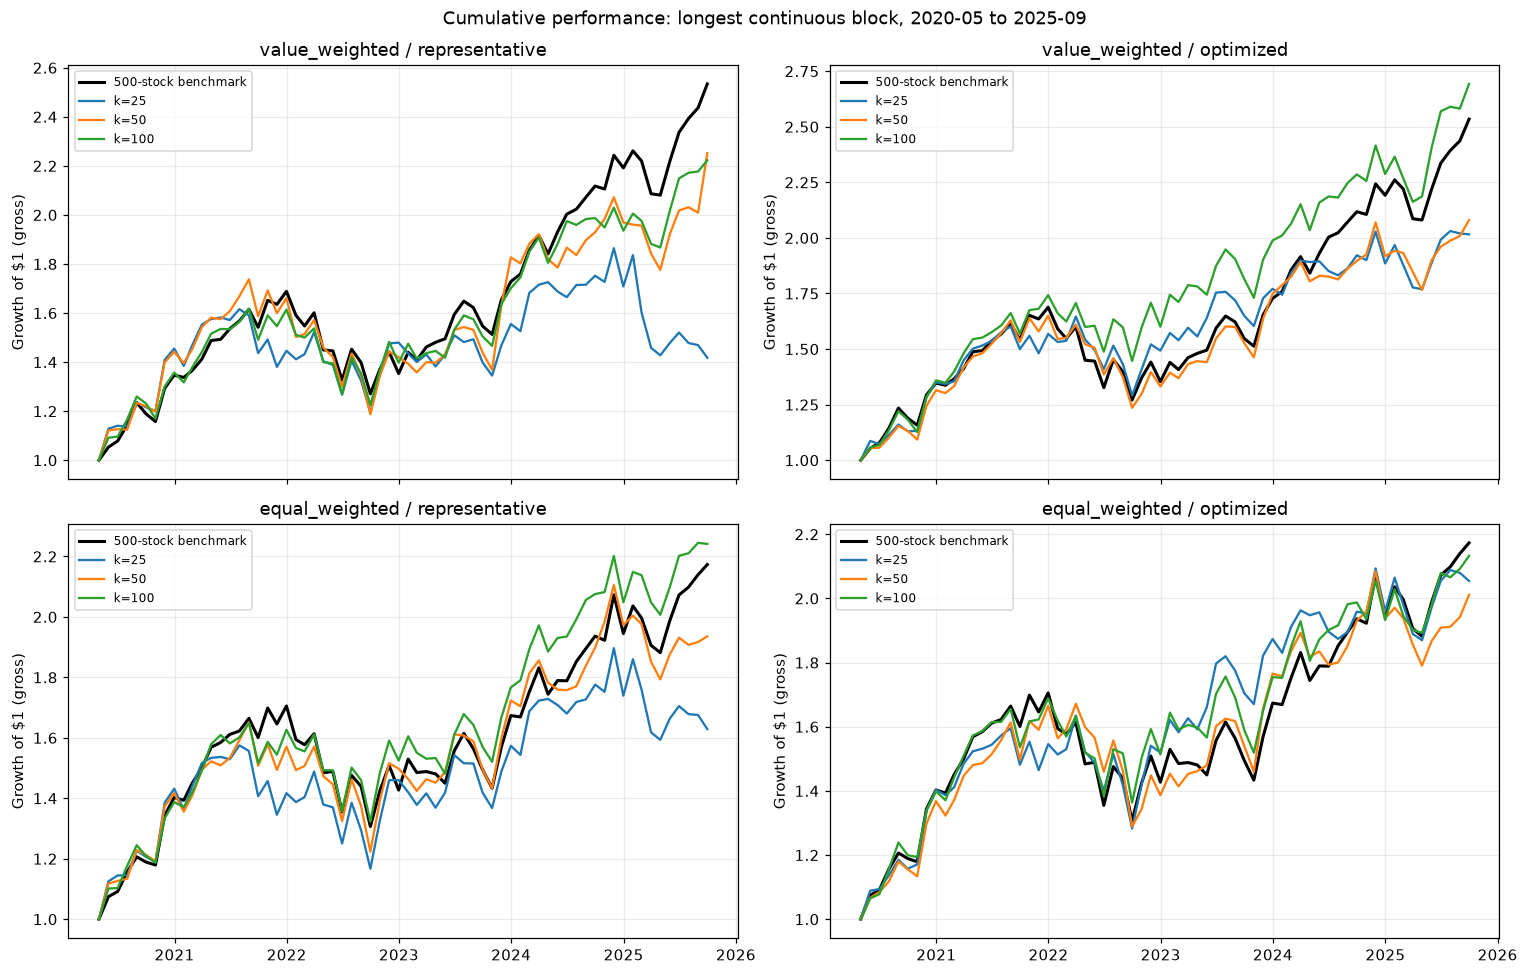

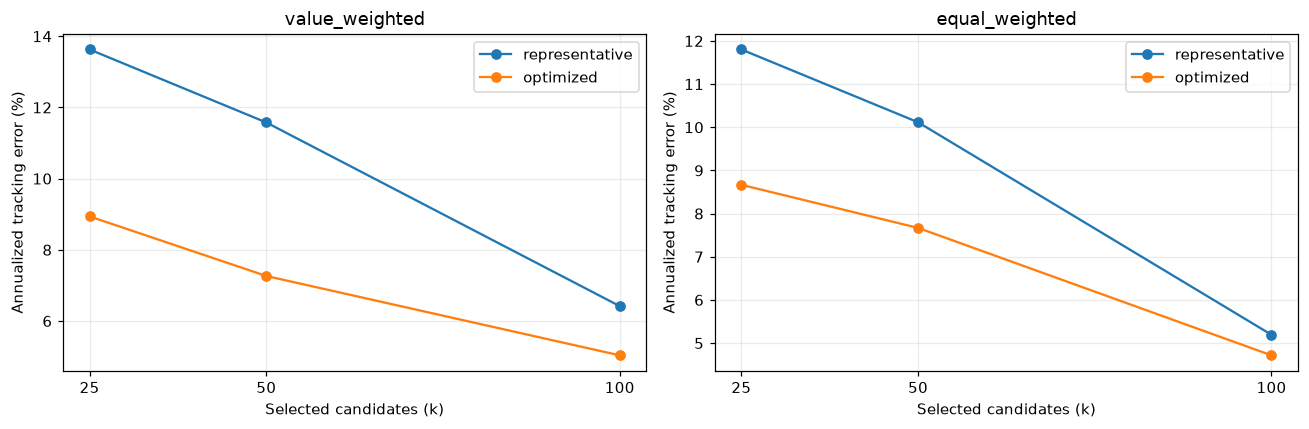

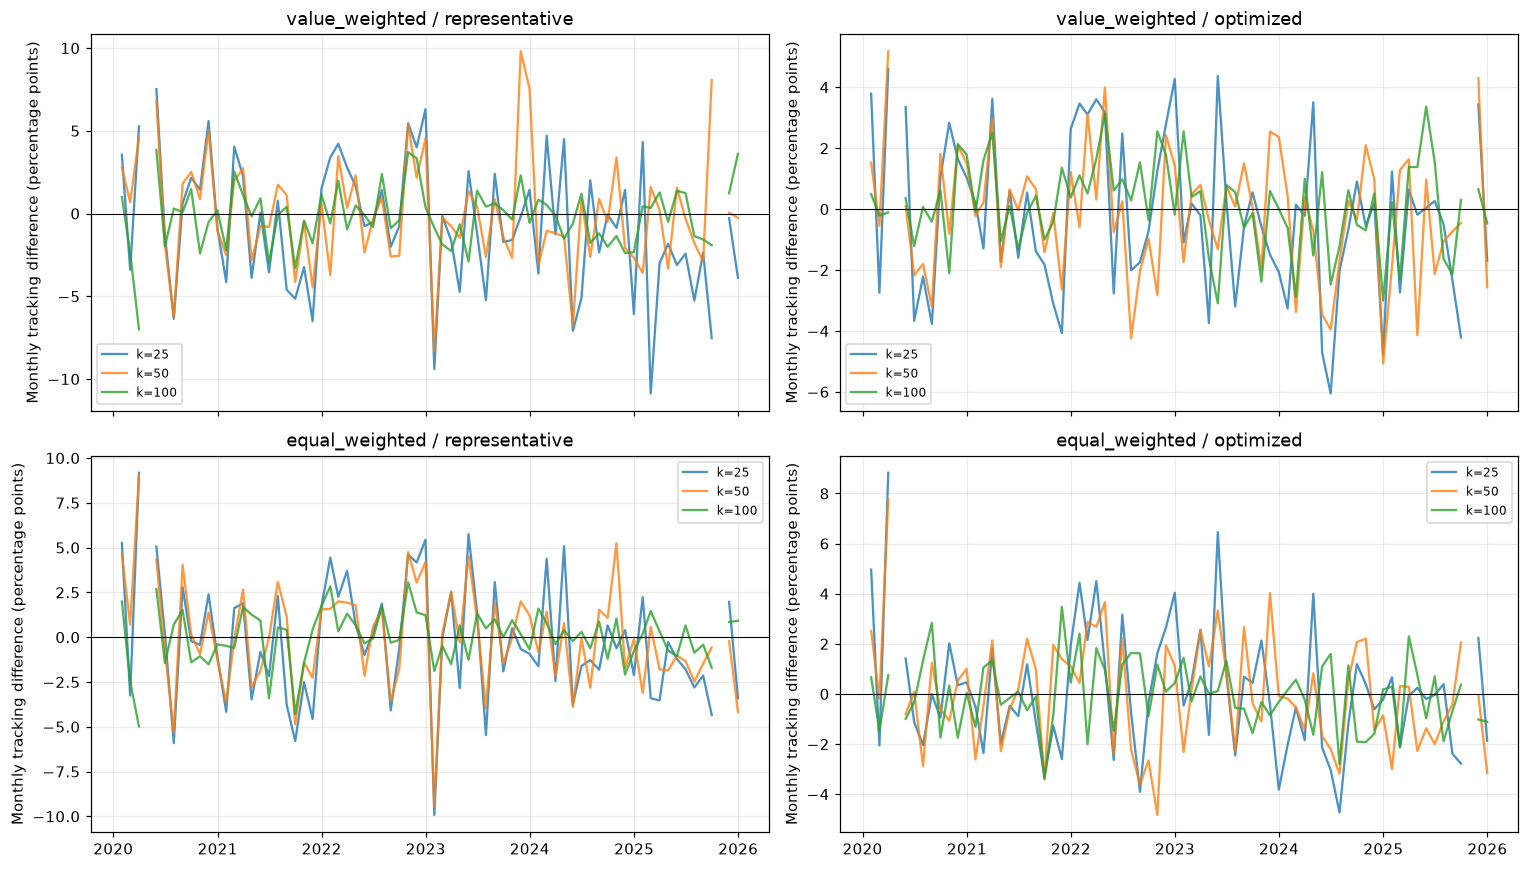

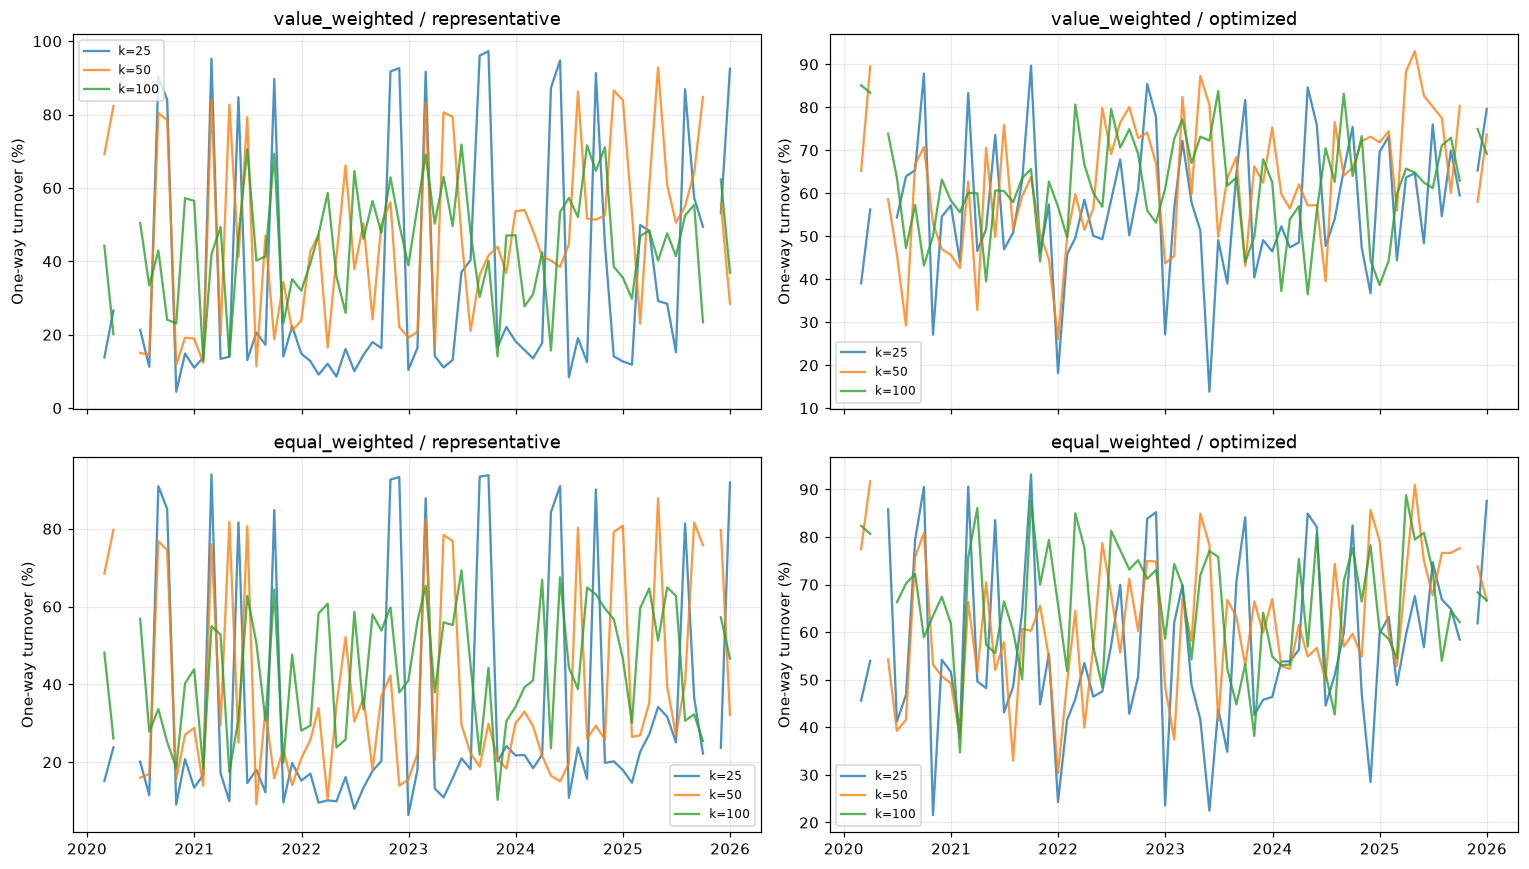

In [6]:
def plot_results(summary, curves, output_dir):
    # Calendar-based choice: do not select a block based on portfolio performance.
    lengths = curves.groupby("block")["holding_month"].nunique()
    longest_block = lengths.idxmax()
    block = curves.loc[curves["block"].eq(longest_block)]
    first, last = block["holding_month"].min(), block["holding_month"].max()
    figs = {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for row, benchmark in enumerate(BENCHMARKS):
        for col, method in enumerate(METHODS):
            ax = axes[row, col]
            subset = block.loc[block["benchmark"].eq(benchmark) & block["method"].eq(method)]
            base = subset.loc[subset["k"].eq(K_VALUES[0])].sort_values("holding_month")
            # Include the initial dollar at the previous month-end.
            dates = pd.PeriodIndex([first - 1] + base["holding_month"].tolist()).to_timestamp("M")
            ax.plot(dates, np.r_[1.0, base["benchmark_wealth"]], color="black",
                    linewidth=2, label="500-stock benchmark")
            for k in K_VALUES:
                g = subset.loc[subset["k"].eq(k)].sort_values("holding_month")
                ax.plot(dates, np.r_[1.0, g["portfolio_wealth"]], label=f"k={k}")
            ax.set_title(f"{benchmark} / {method}")
            ax.set_ylabel("Growth of $1 (gross)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Cumulative performance: longest continuous block, {first} to {last}")
    fig.tight_layout()
    figs["cumulative_returns"] = fig

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, benchmark in zip(axes, BENCHMARKS):
        for method in METHODS:
            g = summary.loc[summary["benchmark"].eq(benchmark) & summary["method"].eq(method)].sort_values("k")
            ax.plot(g["k"], 100 * g["tracking_error_annualized"], marker="o", label=method)
        ax.set(title=benchmark, xlabel="Selected candidates (k)",
               ylabel="Annualized tracking error (%)", xticks=list(K_VALUES))
        ax.legend()
    fig.tight_layout()
    figs["tracking_error_by_size"] = fig

    calendar = pd.period_range(curves["holding_month"].min(), curves["holding_month"].max(), freq="M")
    for field, label, filename in [
        ("active_return", "Monthly tracking difference (percentage points)", "tracking_differences"),
        ("turnover", "One-way turnover (%)", "turnover"),
    ]:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
        for row, benchmark in enumerate(BENCHMARKS):
            for col, method in enumerate(METHODS):
                ax = axes[row, col]
                for k in K_VALUES:
                    g = curves.loc[curves["benchmark"].eq(benchmark) & curves["method"].eq(method)
                                   & curves["k"].eq(k)].set_index("holding_month")
                    values = g[field].reindex(calendar)
                    ax.plot(calendar.to_timestamp("M"), 100 * values, label=f"k={k}", alpha=0.8)
                ax.set_title(f"{benchmark} / {method}")
                ax.set_ylabel(label)
                if field == "active_return":
                    ax.axhline(0, color="black", linewidth=0.7)
                ax.legend(fontsize=8)
        fig.tight_layout()
        figs[filename] = fig
    for filename, fig in figs.items():
        fig.savefig(output_dir / f"{filename}.png", dpi=180, bbox_inches="tight")
    return figs

figures = plot_results(summary, curves, OUTPUT_DIR)
plt.show()


## 7. Interpretation and handoff

Use the results to answer:
1. How closely do the 25-, 50-, and 100-stock portfolios track the full benchmark out of sample?
2. Do optimized weights reduce tracking error compared with representative weights, and at what turnover?
3. Which test months remain unresolved, and how much benchmark mass was covered by Part 2's eligible subset?

The reported monthly comparison pools common valid observations across the requested 2020–2025 period. If gaps remain, this is not a continuous six-year investment record. Cumulative returns and CAGR are reported by continuous block; the cumulative chart shows the longest such block. Each block's value starts at $1.

The training policy is Person 3's recorded policy: keep at least 48 complete observations within each 60-month window. Part 4 verifies it and does not change the weights or fill missing test returns. Part 3 files and its notebook are read-only inputs.

Current-run outputs: `all_strategy_months.csv`, `common_monthly_results.csv`, `summary_statistics.csv`, `continuous_block_statistics.csv`, `tracking_error_comparison.csv`, `coverage_audit.csv`, `coverage_by_month.csv`, `training_coverage.csv`, `excluded_training_observations.csv`, `upstream_weight_diagnostics.csv`, `invalid_held_stock_returns.csv`, `missing_benchmark_constituents.csv`, four PNG figures, and `run_manifest.json`.

An older file named `upstream_excluded_formation_months.csv`, if present, is from the previous run and is not a current-run input or output.


In [7]:
import hashlib
import platform

manifest = {
    "requested_start": START_HOLDING, "requested_end": END_HOLDING,
    "lookback_months_upstream": LOOKBACK, "k_values": list(K_VALUES),
    "minimum_training_observations": MIN_TRAINING_MONTHS,
    "training_policy": sorted(diagnostics["missing_benchmark_policy"].unique().tolist()),
    "actual_training_observations_min": int(diagnostics["n_training_months"].min()),
    "actual_training_observations_max": int(diagnostics["n_training_months"].max()),
    "common_months": int(panel["holding_month"].nunique()),
    "continuous_blocks": int(panel["block"].nunique()),
    "excluded_months": int((~coverage_by_month["included"]).sum()),
    "returns": "decimal monthly total returns, gross of costs",
    "turnover": "half-L1 vs prior drifted holdings; initial investment excluded",
    "missing_policy": "invalidate observation; compare all 12 strategies on common dates",
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__},
    "inputs": {},
}
for name, path in paths.items():
    if path.exists():
        digest = hashlib.sha256()
        with path.open("rb") as stream:
            for chunk in iter(lambda: stream.read(1024 * 1024), b""):
                digest.update(chunk)
        manifest["inputs"][name] = {"path": str(path), "sha256": digest.hexdigest()}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print("Saved tables and figures to:", OUTPUT_DIR)
print("Common evaluation interval:", panel["holding_month"].min(), "through", panel["holding_month"].max())


Saved tables and figures to: /Users/yujiezhu/Documents/Optimization_Project/Optimization-Project-AFYC/part4_output
Common evaluation interval: 2020-01 through 2025-12


## 8. Summary

This project tests whether portfolios of 25, 50, or 100 selected stocks can replicate the full 500-stock value-weighted and equal-weighted benchmarks. Part 4 applies Person 3's saved weights to the following month's returns and evaluates all 12 strategies on the same dates.

**Evaluation coverage.** The requested period is January 2020–December 2025. The current run includes **70 of 72 months**; April 2020 and October 2025 are excluded because benchmark returns are unavailable. Part 3 fits using 48–60 complete observations within each 60-month window.

**Main findings.** Annualized tracking error decreases as portfolio size increases for every benchmark/method combination. Optimized weights achieve lower out-of-sample tracking error than representative weights at every tested size, but also incur higher average turnover.

The 100-stock portfolios provide the lowest tracking errors within each benchmark/method combination:

| Benchmark | Weighting method | Annualized tracking error | Return correlation | Mean monthly one-way turnover |
|---|---|---:|---:|---:|
| Value-weighted | Representative | 6.42% | 0.9551 | 44.61% |
| Value-weighted | Optimized | 5.03% | 0.9626 | 61.94% |
| Equal-weighted | Representative | 5.19% | 0.9667 | 44.18% |
| Equal-weighted | Optimized | 4.72% | 0.9671 | 66.04% |

Lower tracking error does not guarantee identical cumulative values. For the 100-stock optimized portfolios, the annualized arithmetic mean tracking difference is **+1.34 percentage points** against the value-weighted benchmark and **−0.61 percentage points** against the equal-weighted benchmark.

**Conclusion and limitations.** The 100-stock optimized portfolios give the closest monthly replication by tracking error among the tested alternatives. Their higher turnover creates a transaction-cost tradeoff that this gross-of-cost backtest does not quantify. Statistics are conditional on the 70 common valid months. Cumulative returns restart after each gap; the main cumulative chart covers the longest continuous block, May 2020–September 2025. Resolve the two missing test months before presenting a continuous six-year investment record.

These findings summarize the saved current run and should be refreshed if the inputs, portfolio methods, or evaluation period change.
